# Attribute Mining Window Sweep — EDA

Cross-configuration EDA of the attribute-mining pipeline, sourced from
`artifacts/mining/*/attribute_mining/` -- the 45 mining runs written by
`src/thesis/shell-scripts/sweep_attribute_schema.sh` (one per combination of
`min_growth_rate x max_depth x mine_frac`). Every one of the 45 grid points was
actually run, so `config.yaml` + `metadata.json` in each run dir is ground truth for
which configuration produced it -- no log scraping, no assumptions about coverage.

(The per-window/per-run stability report generator,
`thesis.visualization.mining.attribute_window_sweep.generate_thesis_report`, still
exists for one-off `run_attribute_mining_window_sweep.py` outputs, but this notebook
no longer depends on it -- that data source only covers whatever ad hoc sweeps happen
to be on disk, not the full grid.)

In [1]:
from __future__ import annotations

import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)

FIGURES_DIR = Path("../../../artifacts/experiments/attribute_mining_parameter_grid/thesis_figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
# Fixed categorical colours, assigned once and reused throughout -- never
# re-derived per plot, so the same growth_rate/max_depth always gets the same
# colour across every figure in this notebook.
GRAN_PALETTE = ["#4477AA", "#EE6677", "#228833", "#CCBB44", "#66CCEE", "#AA3377"]
ATTACK_COLOR = "#CC3311"   # warm -> attack-leaning / attack class
BENIGN_COLOR = "#4477AA"   # cool -> benign-leaning / benign class
NEUTRAL_COLOR = "#BBBBBB"


def gran_color_map(grans: list[float]) -> dict[float, str]:
    return {g: GRAN_PALETTE[i % len(GRAN_PALETTE)] for i, g in enumerate(sorted(grans))}


def savefig(fig: plt.Figure, name: str) -> None:
    """Save a 300dpi copy for the thesis alongside the inline notebook display."""
    path = FIGURES_DIR / name
    fig.savefig(path, dpi=300, bbox_inches="tight")
    print(f"  saved {path}")


def strip_axes(ax) -> None:
    ax.grid(axis="y", alpha=0.25)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)


def base_feature(token: str) -> str:
    """Strip NOT_/threshold suffix to get the underlying attribute name, e.g.
    'NOT_multi_target' -> 'multi_target',
    'signature_matches_per_day_le_143.7' -> 'signature_matches_per_day'.
    """
    t = token.strip()
    if t.startswith("NOT_"):
        t = t[4:]
    m = re.match(r"^(.*)_(le|gt)_[-0-9.eE]+$", t)
    return m.group(1) if m else t

## 1. Full-scenario parameter grid (mining output)

Each of the 45 `min_growth_rate x max_depth x mine_frac` combinations was mined on the
**full** cscas dataset by `src/thesis/shell-scripts/sweep_attribute_schema.sh`, one run
per combination under `artifacts/mining/<timestamp>_symbolic_cscas/attribute_mining/`.
`config.yaml` records the exact thresholds used; `metadata.json`'s `n_alert_groups`
identifies `mine_frac` (as a fraction of the largest run's `n_alert_groups`). This is
the only source of a `mine_frac` (data-fraction) sweep in this repo: how much of the
dataset does the mining pipeline actually need to see before its output schema
stabilizes?

`mined_attribute_features.csv` in each run dir is the full labelled feature set (Step 1
contrast predicates + Step 2 decision-tree leaves); `contrast_stats_all.csv` /
`contrast_survivors.csv` additionally expose which Step 1 candidates were dropped and
why.

In [3]:
import json

import yaml

MINING_ROOT = Path("../../../artifacts/mining")

rows = []
for run_dir in sorted(MINING_ROOT.iterdir()):
    mining_dir = run_dir / "attribute_mining"
    cfg_path, meta_path = mining_dir / "config.yaml", mining_dir / "metadata.json"
    if not (cfg_path.exists() and meta_path.exists()):
        continue
    cfg = yaml.safe_load(cfg_path.read_text())
    meta = json.loads(meta_path.read_text())
    rows.append({
        "run_dir": run_dir.name,
        "growth_rate": cfg["contrast"]["min_growth_rate"],
        "max_depth": cfg["tree"]["max_depth"],
        "min_attack_coverage": cfg["contrast"]["min_attack_coverage"],
        "min_benign_coverage": cfg["contrast"]["min_benign_coverage"],
        "n_alert_groups": meta["n_alert_groups"],
        "mining_dir": mining_dir,
    })

grid_df = pd.DataFrame(rows)
# mine_frac isn't stored anywhere directly -- it's implicit in how much of the dataset
# each run saw, so recover it as n_alert_groups relative to the largest (mine_frac=1.0)
# run rather than trusting a directory-name convention.
total_alert_groups = grid_df["n_alert_groups"].max()
grid_df["mine_frac"] = (grid_df["n_alert_groups"] / total_alert_groups).round(2)
grid_df = grid_df.sort_values(["growth_rate", "max_depth", "mine_frac"]).reset_index(drop=True)

assert len(grid_df) == 45, f"expected the full 3x3x5 grid, found {len(grid_df)} mining runs"

GROWTH_RATES = sorted(grid_df["growth_rate"].unique())
MAX_DEPTHS = sorted(grid_df["max_depth"].unique())
MINE_FRACS = sorted(grid_df["mine_frac"].unique())

print(f"Found {len(grid_df)} mining runs under {MINING_ROOT.resolve()}")
print(f"growth_rate={GROWTH_RATES}  max_depth={MAX_DEPTHS}  mine_frac={MINE_FRACS}")

Found 45 mining runs under /Users/annavisman/stack/TUDelft/thesis/msc-thesis/artifacts/mining
growth_rate=[np.float64(3.0), np.float64(4.0), np.float64(5.0)]  max_depth=[np.int64(3), np.int64(4), np.int64(5)]  mine_frac=[np.float64(0.1), np.float64(0.2), np.float64(0.33), np.float64(0.5), np.float64(1.0)]


In [4]:
import ast


def grid_point_stats(row: pd.Series) -> dict:
    feats = pd.read_csv(row["mining_dir"] / "mined_attribute_features.csv")
    feats["itemset"] = feats["itemset"].apply(ast.literal_eval)
    contrast = feats[feats["mining_type"] == "contrast_categorical"]
    tree = feats[feats["mining_type"] == "decision_tree_rule"]
    tree_attack = tree[tree["source_label"] == "attack"]

    base_counts: dict[str, int] = {}
    for itemset in tree["itemset"]:
        for tok in itemset:
            feat = base_feature(tok)
            base_counts[feat] = base_counts.get(feat, 0) + 1
    top2_feature_share = (
        sum(sorted(base_counts.values(), reverse=True)[:2]) / len(tree) if base_counts else np.nan
    )

    return {
        "n_features": len(feats),
        "n_contrast": len(contrast),
        "n_tree_leaves": len(tree),
        "mean_tree_confidence_attack": tree_attack["confidence_attack"].mean() if len(tree_attack) else np.nan,
        "mean_rule_length": tree["itemset"].apply(len).mean() if len(tree) else np.nan,
        "n_distinct_base_features": len(base_counts),
        "top2_feature_share": top2_feature_share,
        # Exact categorical itemsets (Step 1) vs. threshold-stripped base attributes used
        # by tree leaves (Step 2), kept separately -- they converge very differently
        # across mine_frac (see 1.2): Step 1's vocabulary is a small fixed alphabet of
        # categorical values, Step 2's splits are continuous thresholds that shift with
        # the data actually seen.
        "_contrast_itemset_set": frozenset(t[0] for t in contrast["itemset"]),
        "_tree_base_set": frozenset(base_feature(tok) for itemset in tree["itemset"] for tok in itemset),
    }


grid_df = pd.concat([grid_df, grid_df.apply(grid_point_stats, axis=1).apply(pd.Series)], axis=1)


def jaccard_vs_full(row: pd.Series, fixed_col: str, set_col: str) -> float:
    """Jaccard of `set_col` against this row's own mine_frac=1.0 counterpart, holding
    `fixed_col` constant (the parameter set_col's step doesn't depend on)."""
    ref = grid_df[(grid_df[fixed_col] == row[fixed_col]) & (grid_df["mine_frac"] == 1.0)]
    a, b = row[set_col], ref.iloc[0][set_col]
    return len(a & b) / len(a | b) if (a or b) else 1.0


grid_df["jaccard_contrast_vs_full"] = grid_df.apply(
    jaccard_vs_full, axis=1, fixed_col="growth_rate", set_col="_contrast_itemset_set"
)
grid_df["jaccard_tree_vs_full"] = grid_df.apply(
    jaccard_vs_full, axis=1, fixed_col="max_depth", set_col="_tree_base_set"
)

GR_COLORS = gran_color_map(GROWTH_RATES)
MD_COLORS = gran_color_map(MAX_DEPTHS)

grid_df.drop(columns=["mining_dir", "_contrast_itemset_set", "_tree_base_set"]).describe().round(3)

,growth_rate,max_depth,min_attack_coverage,min_benign_coverage,n_alert_groups,mine_frac,n_features,n_contrast,n_tree_leaves,mean_tree_confidence_attack,mean_rule_length,n_distinct_base_features,top2_feature_share,jaccard_contrast_vs_full,jaccard_tree_vs_full
count,45.000,45.000,45.00,45.00,45.000,45.000,45.000,45.000,45.000,45.000,45.000,45.000,45.000,45.000,45.000
mean,4.000,4.000,0.05,0.05,594407.600,0.426,263.667,257.133,6.533,0.521,2.938,4.733,1.937,0.994,0.583
std,0.826,0.826,0.00,0.00,446904.119,0.320,48.291,48.218,2.302,0.267,0.512,1.827,0.172,0.011,0.223
min,3.000,3.000,0.05,0.05,139532.000,0.100,184.000,180.000,4.000,0.200,2.250,3.000,1.571,0.972,0.400
25%,3.000,3.000,0.05,0.05,279064.000,0.200,196.000,184.000,5.000,0.333,2.600,3.000,1.750,1.000,0.429
50%,4.000,4.000,0.05,0.05,460456.000,0.330,289.000,283.000,7.000,0.500,2.857,5.000,2.000,1.000,0.500
75%,5.000,5.000,0.05,0.05,697662.000,0.500,297.000,291.000,7.000,0.500,3.429,6.000,2.111,1.000,0.667
max,5.000,5.000,0.05,0.05,1395324.000,1.000,317.000,305.000,12.000,1.000,3.667,9.000,2.143,1.000,1.000


### 1.1 Parameter interactions: schema size, rule count, feature reuse

Every cell below is a real mined schema, so the interaction between `growth_rate`,
`max_depth`, and `mine_frac` is directly visible: each row is one metric, each column
one `mine_frac`, and each heatmap cell one `(growth_rate, max_depth)` combination.
`top2_feature_share` is the mean number of Step 2 leaves using one of the two
most-reused base attributes -- a rising value means the tree is leaning on a shrinking
core of signals rather than spreading across independent ones.

  saved ../../../artifacts/experiments/attribute_mining_parameter_grid/thesis_figures/grid_step1_step2_interactions.png


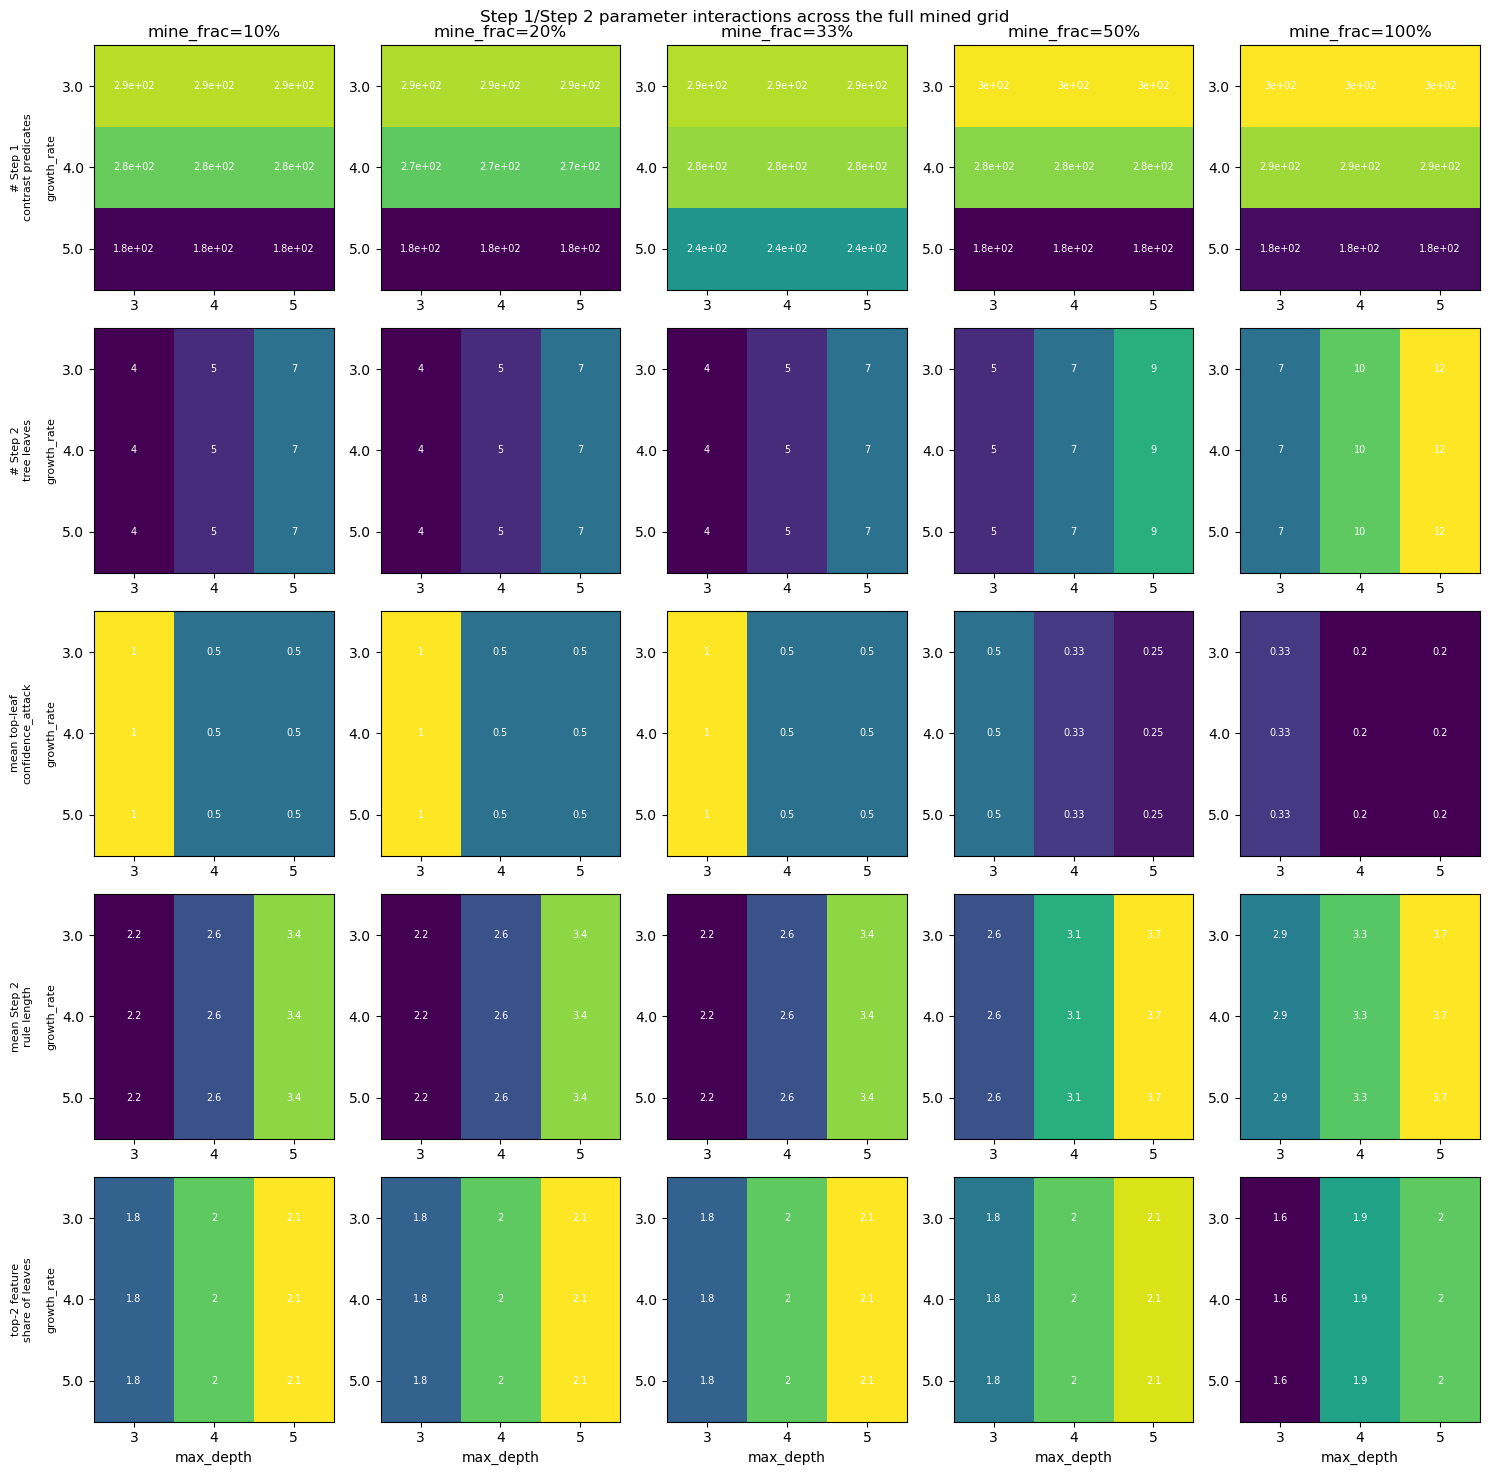

In [5]:
grid_metrics = [
    ("n_contrast", "# Step 1\ncontrast predicates"),
    ("n_tree_leaves", "# Step 2\ntree leaves"),
    ("mean_tree_confidence_attack", "mean top-leaf\nconfidence_attack"),
    ("mean_rule_length", "mean Step 2\nrule length"),
    ("top2_feature_share", "top-2 feature\nshare of leaves"),
]

fig, axes = plt.subplots(len(grid_metrics), len(MINE_FRACS), figsize=(3.0 * len(MINE_FRACS), 3.0 * len(grid_metrics)))
for row_i, (metric, label) in enumerate(grid_metrics):
    vmin, vmax = grid_df[metric].min(), grid_df[metric].max()
    for col_i, mf in enumerate(MINE_FRACS):
        ax = axes[row_i, col_i]
        pivot = (
            grid_df[grid_df.mine_frac == mf]
            .pivot(index="growth_rate", columns="max_depth", values=metric)
            .reindex(index=GROWTH_RATES, columns=MAX_DEPTHS)
        )
        ax.imshow(pivot.values, cmap="viridis", vmin=vmin, vmax=vmax, aspect="auto")
        for i in range(pivot.shape[0]):
            for j in range(pivot.shape[1]):
                ax.text(j, i, f"{pivot.values[i, j]:.2g}", ha="center", va="center", fontsize=7, color="white")
        ax.set_xticks(range(len(MAX_DEPTHS)))
        ax.set_xticklabels(MAX_DEPTHS)
        ax.set_yticks(range(len(GROWTH_RATES)))
        ax.set_yticklabels(GROWTH_RATES)
        if row_i == 0:
            ax.set_title(f"mine_frac={mf:.0%}")
        if col_i == 0:
            ax.set_ylabel(label + "\n\ngrowth_rate", fontsize=8)
        if row_i == len(grid_metrics) - 1:
            ax.set_xlabel("max_depth")

fig.suptitle("Step 1/Step 2 parameter interactions across the full mined grid")
fig.tight_layout()
savefig(fig, "grid_step1_step2_interactions.png")
plt.show()

### 1.2 Why Step 1 candidates get dropped

`contrast_stats_all.csv` has every candidate Step 1 considered; `contrast_survivors.csv`
has the ones that made it through. Diffing the two and re-deriving which threshold each
dropped candidate failed (mirroring the filter logic in
`thesis.mining.attribute_contrast_mining`) shows whether tightening `min_growth_rate`
mostly removes genuinely non-discriminative candidates (`growth_rate_too_close_to_1`,
expected and healthy) or starts cutting into candidates that look discriminative but
lack coverage. Shown at `mine_frac=100%` (`max_depth` doesn't affect Step 1, so one
`max_depth` value is representative).

  saved ../../../artifacts/experiments/attribute_mining_parameter_grid/thesis_figures/grid_drop_reasons.png


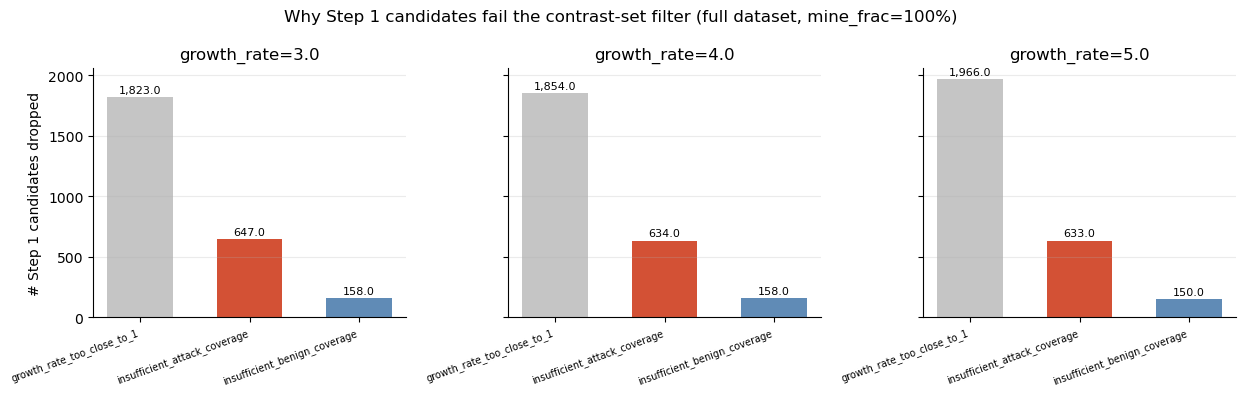

In [6]:
reason_order = ["growth_rate_too_close_to_1", "insufficient_attack_coverage", "insufficient_benign_coverage", "other"]
reason_colors = [NEUTRAL_COLOR, ATTACK_COLOR, BENIGN_COLOR, "#DDCC77"]

fig, axes = plt.subplots(1, len(GROWTH_RATES), figsize=(4.2 * len(GROWTH_RATES), 4), sharey=True)
for ax, gr in zip(axes, GROWTH_RATES):
    row = grid_df[
        (grid_df.growth_rate == gr) & (grid_df.max_depth == MAX_DEPTHS[0]) & (grid_df.mine_frac == 1.0)
    ].iloc[0]
    stats_all = pd.read_csv(row["mining_dir"] / "contrast_stats_all.csv")
    survivors = pd.read_csv(row["mining_dir"] / "contrast_survivors.csv")
    dropped = stats_all[~stats_all["itemset"].isin(set(survivors["itemset"]))].copy()

    inv_threshold = 1.0 / gr if gr > 0 else float("inf")
    attack_leaning = dropped["growth_rate"] >= gr
    benign_leaning = (dropped["confidence_benign"] > 0) & (dropped["growth_rate"] <= inv_threshold)
    conditions = [
        ~(attack_leaning | benign_leaning),
        attack_leaning & (dropped["confidence_attack"] < row["min_attack_coverage"]),
        benign_leaning & (dropped["confidence_benign"] < row["min_benign_coverage"]),
    ]
    dropped["reason"] = np.select(conditions, reason_order[:3], default="other")
    counts = dropped["reason"].value_counts().reindex(reason_order).dropna()

    x = np.arange(len(counts))
    ax.bar(x, counts.values, color=reason_colors[: len(counts)], alpha=0.85, width=0.6)
    for i, v in enumerate(counts.values):
        ax.text(i, v + counts.values.max() * 0.01, f"{v:,}", ha="center", va="bottom", fontsize=8)
    ax.set_xticks(x)
    ax.set_xticklabels(counts.index, rotation=20, ha="right", fontsize=7)
    ax.set_title(f"growth_rate={gr}")
    strip_axes(ax)

axes[0].set_ylabel("# Step 1 candidates dropped")
fig.suptitle("Why Step 1 candidates fail the contrast-set filter (full dataset, mine_frac=100%)")
fig.tight_layout()
savefig(fig, "grid_drop_reasons.png")
plt.show()

### 1.3 Data efficiency: how much data does mining actually need?

For each row above, `mine_frac` measures the same schema at increasing fractions of the
full dataset -- so it doubles as a convergence study: does the mined schema at
`mine_frac=10%` already look like the one mined on all the data, or does it keep
changing all the way to 100%? Jaccard is computed against each combination's own
`mine_frac=100%` schema, holding the parameter that step doesn't depend on constant
(Step 1 never depends on `max_depth`, Step 2 never depends on `growth_rate` -- confirmed
by the flat rows/columns in the heatmaps above).

  saved ../../../artifacts/experiments/attribute_mining_parameter_grid/thesis_figures/grid_data_efficiency.png


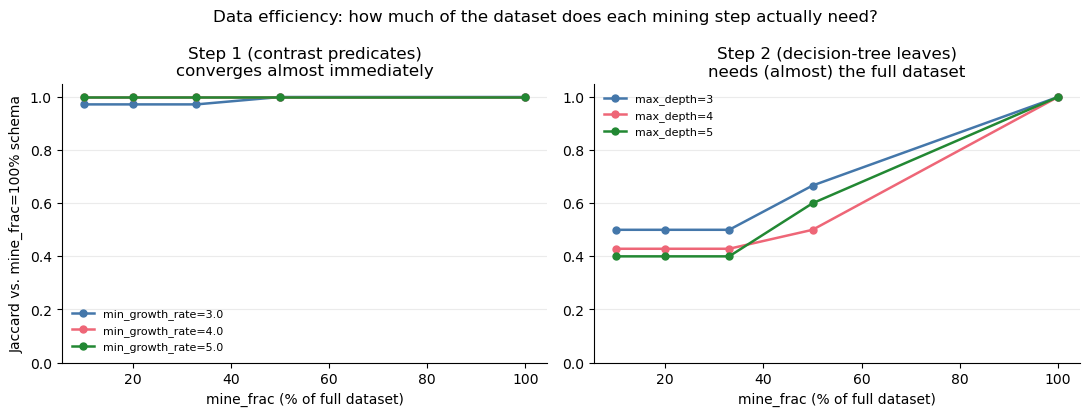

Step 1 Jaccard at mine_frac=10%: 0.991 mean
Step 2 Jaccard at mine_frac=10%: 0.443 mean


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

ax = axes[0]
for gr in GROWTH_RATES:
    sub = grid_df[(grid_df.max_depth == MAX_DEPTHS[0]) & (grid_df.growth_rate == gr)].sort_values("mine_frac")
    ax.plot(
        sub["mine_frac"] * 100, sub["jaccard_contrast_vs_full"],
        marker="o", markersize=5, linewidth=1.8, color=GR_COLORS[gr], label=f"min_growth_rate={gr}",
    )
ax.set_title("Step 1 (contrast predicates)\nconverges almost immediately")
ax.set_xlabel("mine_frac (% of full dataset)")
ax.set_ylabel("Jaccard vs. mine_frac=100% schema")
ax.set_ylim(0, 1.05)
ax.legend(frameon=False, fontsize=8)
strip_axes(ax)

ax = axes[1]
for md in MAX_DEPTHS:
    sub = grid_df[(grid_df.growth_rate == GROWTH_RATES[0]) & (grid_df.max_depth == md)].sort_values("mine_frac")
    ax.plot(
        sub["mine_frac"] * 100, sub["jaccard_tree_vs_full"],
        marker="o", markersize=5, linewidth=1.8, color=MD_COLORS[md], label=f"max_depth={md}",
    )
ax.set_title("Step 2 (decision-tree leaves)\nneeds (almost) the full dataset")
ax.set_xlabel("mine_frac (% of full dataset)")
ax.set_ylim(0, 1.05)
ax.legend(frameon=False, fontsize=8)
strip_axes(ax)

fig.suptitle("Data efficiency: how much of the dataset does each mining step actually need?")
fig.tight_layout()
savefig(fig, "grid_data_efficiency.png")
plt.show()

print(
    f"Step 1 Jaccard at mine_frac=10%: "
    f"{grid_df.loc[grid_df.mine_frac == MINE_FRACS[0], 'jaccard_contrast_vs_full'].mean():.3f} mean"
)
print(
    f"Step 2 Jaccard at mine_frac=10%: "
    f"{grid_df.loc[grid_df.mine_frac == MINE_FRACS[0], 'jaccard_tree_vs_full'].mean():.3f} mean"
)

### 1.4 Consolidated grid table

All 45 combinations, for pulling exact numbers into the thesis text or calling
`.to_latex()` directly.

In [8]:
grid_summary_table = grid_df.drop(columns=["mining_dir", "_contrast_itemset_set", "_tree_base_set"]).set_index(
    ["growth_rate", "max_depth", "mine_frac"]
)
grid_summary_table

run_dir  min_attack_coverage  min_benign_coverage  n_alert_groups  n_features  n_contrast  n_tree_leaves  mean_tree_confidence_attack  \
growth_rate max_depth mine_frac                                                                                                                                                                 
3.0         3         0.10       20260706_211132_symbolic_cscas                 0.05                 0.05          139532         296         292              4                     1.000000   
                      0.20       20260706_211244_symbolic_cscas                 0.05                 0.05          279064         294         290              4                     1.000000   
                      0.33       20260706_211411_symbolic_cscas                 0.05                 0.05          460456         295         291              4                     1.000000   
                      0.50       20260706_211605_symbolic_cscas                 0.05                 0.05          697662         309         304              5                     0.500000   
                      1.00       20260706_211826_symbolic_cscas                 0.05                 0.05         1395324         312         305              7                     0.333286   
            4         0.10       20260706_212229_symbolic_cscas                 0.05                 0.05          139532         297         292              5                     0.500000   
                      0.20       20260706_212341_symbolic_cscas                 0.05                 0.05          279064         295         290              5                     0.500000   
                      0.33       20260706_212519_symbolic_cscas                 0.05                 0.05          460456         296         291              5                     0.500000   
                      0.50       20260706_212722_symbolic_cscas                 0.05                 0.05          697662         311         304              7                     0.333333   
                      1.00       20260706_212958_symbolic_cscas                 0.05                 0.05         1395324         315         305             10                     0.200000   
            5         0.10       20260706_213410_symbolic_cscas                 0.05                 0.05          139532         299         292              7                     0.500000   
                      0.20       20260706_213535_symbolic_cscas                 0.05                 0.05          279064         297         290              7                     0.500000   
                      0.33       20260706_213704_symbolic_cscas                 0.05                 0.05          460456         298         291              7                     0.499478   
                      0.50       20260706_213858_symbolic_cscas                 0.05                 0.05          697662         313         304              9                     0.249613   
                      1.00       20260706_214120_symbolic_cscas                 0.05                 0.05         1395324         317         305             12                     0.199838   
4.0         3         0.10       20260706_214512_symbolic_cscas                 0.05                 0.05          139532         280         276              4                     1.000000   
                      0.20       20260706_214624_symbolic_cscas                 0.05                 0.05          279064         278         274              4                     1.000000   
                      0.33       20260706_214758_symbolic_cscas                 0.05                 0.05          460456         289         285              4                     1.000000   
                      0.50       20260706_214955_symbolic_cscas                 0.05                 0.05          697662         288         283              5                     0.500000   
   